# Week 10: Clustering Part 1
Include the following ideas: k-means; specifically elbow method, Silhouette score, feature scaling, and distance metrics.

In [1]:
# Data Science Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn (Machine Learning
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold,
    RepeatedStratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Language Processing
import nltk
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# globals
random_state = 42

In [2]:
def test_num_of_clusters(X, max_k=10, method='elbow'):
    # Test K values and store results
    if method == 'elbow':
        k_values = range(1, max_k + 1)
        inertia = []
        for k in k_values:
            model = make_pipeline(
                StandardScaler(),
                KMeans(n_clusters=k, random_state=42)
            )
            model.fit(X)
            inertia.append(model.named_steps['kmeans'].inertia_)

        # Elbow Method
        plt.plot(k_values, inertia, marker='o')
        plt.xlabel('k')
        plt.ylabel('Inertia')
        plt.title('Elbow Method: Inertia vs. Number of Clusters')
        plt.show()
    
    if method == 'silhouette':
        k_values = range(2, max_k + 1)
        scores = []
        for k in k_values:
            model = make_pipeline(
                StandardScaler(),
                KMeans(n_clusters=k, random_state=42)
            )
            model.fit(X)
            score = silhouette_score(X, model.named_steps['kmeans'].labels_)
            scores.append(score)

        # Silhouette Score
        plt.plot(k_values, scores, marker='o')
        plt.xlabel('k')
        plt.ylabel('Silhouette Scores')
        plt.title('Silhouette Scores vs. Number of Clusters')
        plt.show()

In [35]:
def visualize_clusters(X, labels, y):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    # Get unique labels
    unique_labels = np.unique(y)

    # Choose a colormap
    cmap = plt.get_cmap('coolwarm', len(unique_labels))

    # Plot each label separately for legend
    for i, lbl in enumerate(unique_labels):
        plt.scatter(
            X_2d[y == lbl, 0],
            X_2d[y == lbl, 1],
            s=35,
            color=cmap(i),
            label=f'Label {lbl}',
            alpha=0.5
        )

    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title('Clusters Colored by Target Label')
    plt.legend()
    plt.show()

## Dataset 1: Web Page Phishing Detection

In [4]:
# Load cleaned data
cleaned_webpage = pd.read_csv('cleaned_webpage.csv')
cleaned_webpage.head()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,legitimate
0,37,19,0,3,0,0,0,0,0,0,...,0,1,0,45,0,0,1,1,4,1
1,77,23,1,1,0,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,0
2,126,50,1,4,1,0,1,2,0,3,...,1,0,0,14,4004,5828815,0,1,0,0
3,18,11,0,2,0,0,0,0,0,0,...,1,0,0,62,0,107721,0,0,3,1
4,55,15,0,2,2,0,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,1


In [5]:
# Define X (features) and y (target value)
X = cleaned_webpage.drop(columns=['legitimate'])
y = cleaned_webpage['legitimate']

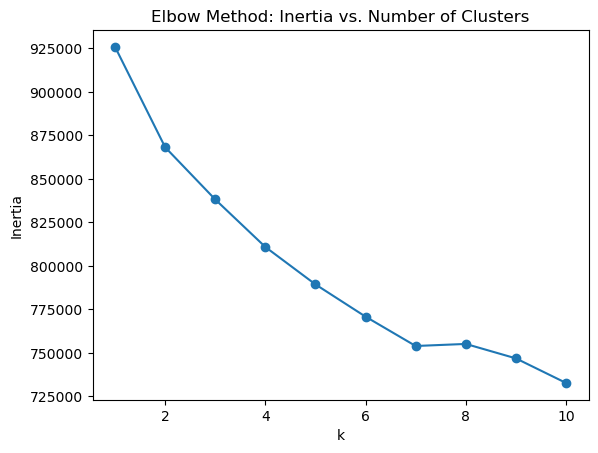

In [6]:
test_num_of_clusters(X, method='elbow')

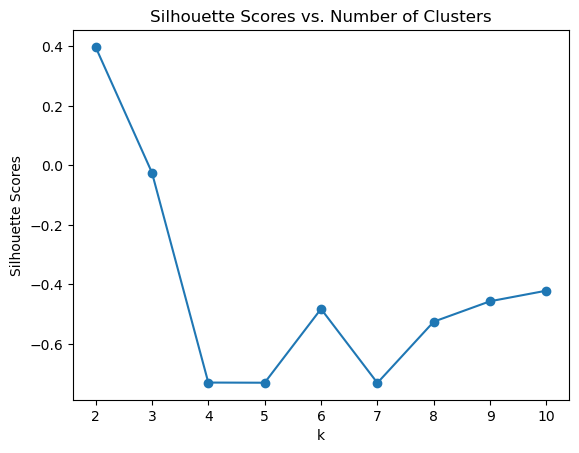

In [7]:
test_num_of_clusters(X, method='silhouette')

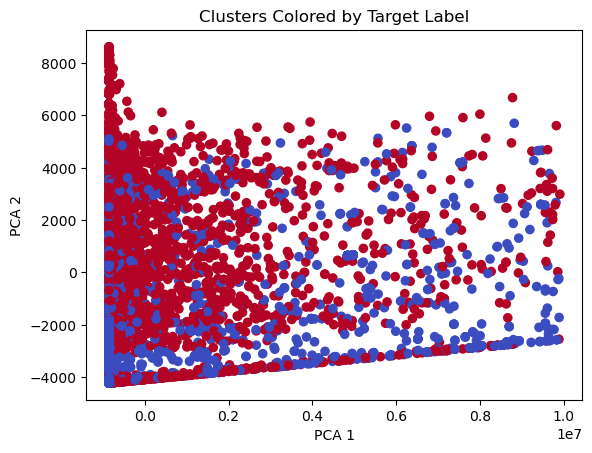

In [8]:
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
visualize_clusters(X, kmeans.labels_, y)

## Dataset 2: Phishing Email Detection

In [9]:
# Load cleaned data
cleaned_email = pd.read_csv('cleaned_email.csv')
cleaned_email.head()

,Email Text,polarity,subjectivity,unique_words,char_count,word_count,uppercase_ratio,symbol_ratio,kw_urgent,kw_verify,kw_account,kw_click,kw_suspend,kw_update,kw_login,kw_confirm,currency_symbol_count,phone_number_count,Safe Email
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0.201493,0.514213,110.0,1030.0,230.0,0.000000,0.059223,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,the other side of * galicismos * * galicismo *...,0.009375,0.084375,53.0,479.0,91.0,0.000000,0.037578,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,re : equistar deal tickets are you still avail...,0.091540,0.515783,102.0,1245.0,305.0,0.000000,0.077108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,\nHello I am your hot lil horny toy.\n I am...,0.260069,0.690278,73.0,688.0,96.0,0.056686,0.162791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0
4,software at incredibly low prices ( 86 % lower...,0.152579,0.505258,60.0,441.0,91.0,0.000000,0.061224,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [10]:
# Define X (features) and y (target value)
X2 = cleaned_email.drop(columns=['Safe Email', 'Email Text'])
y2 = cleaned_email['Safe Email']

In [11]:
# Semantic Clustering
emails = cleaned_email['Email Text'].tolist()
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(emails)

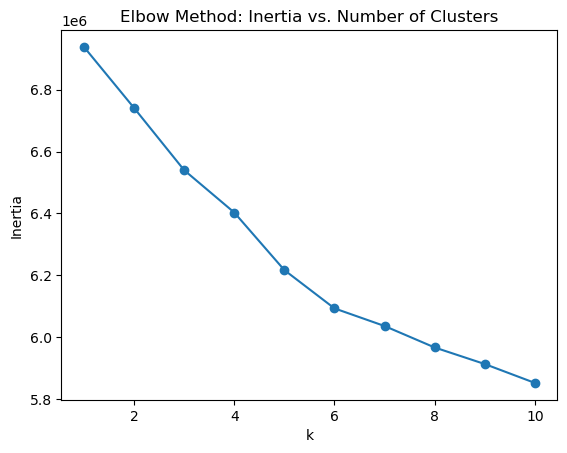

In [12]:
test_num_of_clusters(embeddings, method='elbow')

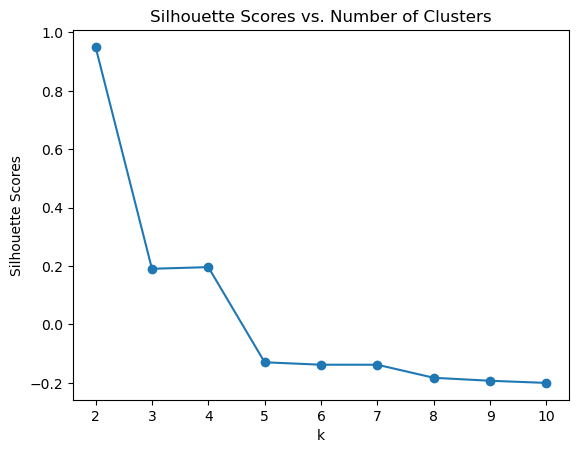

In [13]:
test_num_of_clusters(X2, method='silhouette')

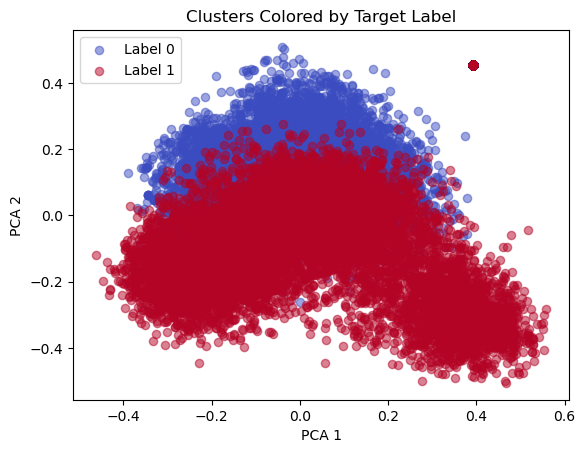

In [36]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(embeddings)
cleaned_email['cluster'] = labels

visualize_clusters(embeddings, labels, y2)

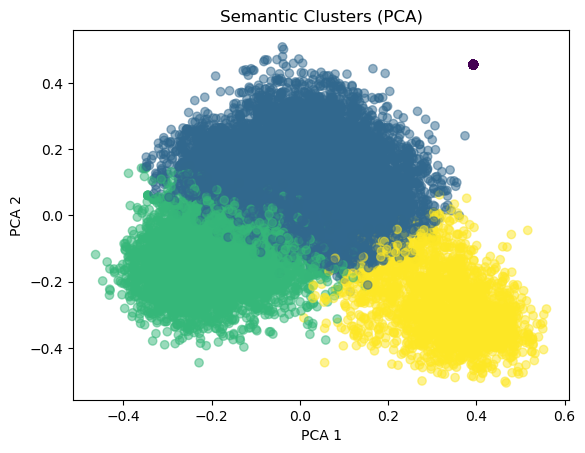

In [39]:
X_2d = PCA(n_components=2).fit_transform(embeddings)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cleaned_email["cluster"], alpha=0.5)
plt.title("Semantic Clusters (PCA)")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [16]:
df = cleaned_email.reset_index(drop=True)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf = vectorizer.fit_transform(df['Email Text'])
terms = vectorizer.get_feature_names_out()

cluster_keywords = {}

for c in sorted(df['cluster'].unique()):
    indices = df[df['cluster'] == c].index
    mean_tfidf = tfidf[indices].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-10:]
    cluster_keywords[c] = list(terms[top_idx])

cluster_keywords

{0: ['dyapex',
  'dyar',
  'dyas',
  'dybkjaer',
  'dybooeafa',
  'dybowski',
  'dyccophul',
  'dydhwichsu',
  'dyapexpathlab',
  'ˆï¼œæ'],
 1: ['just',
  'free',
  'email',
  'net',
  'list',
  'click',
  'www',
  'linux',
  'com',
  'http'],
 2: ['pm',
  'thanks',
  'subject',
  'gas',
  'vince',
  '2000',
  '2001',
  'hou',
  'ect',
  'enron'],
 3: ['linguistic',
  '1998',
  'edu',
  'conference',
  'papers',
  'languages',
  'english',
  'linguistics',
  'university',
  'language']}

## Dataset 3: Credit Card Transactions Fraud Detection Dataset

In [17]:
# Load cleaned data
cleaned_credit_card = pd.read_csv('cleaned_ccd.csv')
cleaned_credit_card.head()

,cc_num,merchant,category,amt,gender,city,state,lat,long,city_pop,job,unix_time,merch_lat,merch_long,age,full_name,max_repeats,is_fraud
0,0,0,0,2.86,0,0,0,33.9659,-80.9355,333497,0,1371816865,33.986391,-81.200714,57,0,3,0
1,1,1,0,29.84,1,1,1,40.3207,-110.4360,302,1,1371816873,39.450498,-109.960431,35,1,4,0
2,2,2,1,41.28,1,2,2,40.6729,-73.5365,34496,2,1371816893,40.495810,-74.196111,55,2,4,0
3,3,3,2,60.05,0,3,3,28.5697,-80.8191,54767,3,1371816915,28.812398,-80.883061,38,3,4,0
4,4,4,3,3.19,0,4,4,44.2529,-85.0170,1126,4,1371816917,44.959148,-85.884734,70,4,3,0


In [18]:
merchant0 = cleaned_credit_card.query('merchant == 0').drop(columns=['merchant', 'category'])

In [19]:
# Define X (features) and y (target value)
X3 = merchant0.drop(columns=['is_fraud'])
X3_scaled = StandardScaler().fit_transform(X3)

y3 = merchant0['is_fraud']

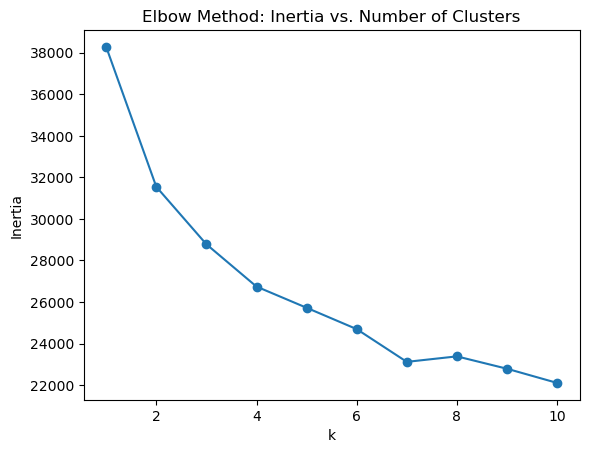

In [20]:
test_num_of_clusters(X3, method='elbow')

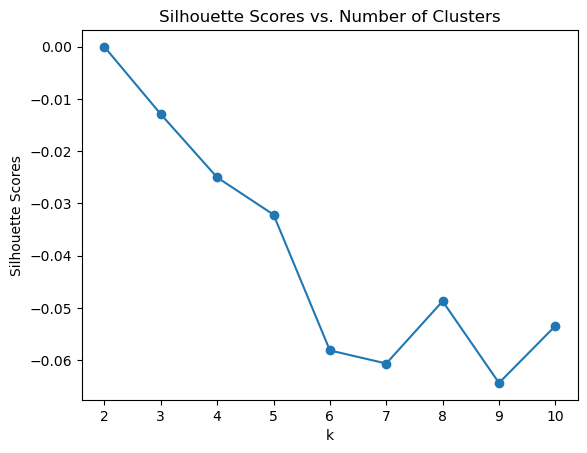

In [21]:
test_num_of_clusters(X3, method='silhouette')

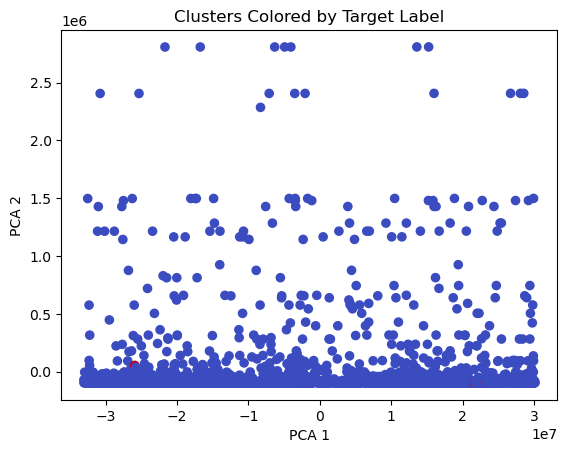

In [22]:
kmeans3 = KMeans(n_clusters=2, random_state=42).fit(X3)
visualize_clusters(X3, kmeans3.labels_, y3)